Run the next cell first. In Colab, add the course key under the key
icon in the left sidebar as `COURSE_API_KEY`, with *Notebook access* on.

In [ ]:
# Course setup. In Colab: add the course key under the key icon (left sidebar)
# as COURSE_API_KEY. On your own machine it uses Ollama instead.
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Pinned, including the transitive ones. Unpinned, pip takes whatever
    # shipped this morning : a newer core moves ModelError, and a newer openai
    # rejects this endpoint's usage payload. Keep in step with requirements.txt.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "langchain==1.3.9", "langchain-core==1.4.7",
                    "langchain-openai==1.3.2", "langchain-classic==1.0.8",
                    "langgraph==1.2.5", "openai==2.41.1", "python-dotenv"],
                   check=True)
    MODEL = "qwen3.8-flash"          # try qwen3.8-max too
    BASE = "https://token-plan.ap-southeast-1.maas.aliyuncs.com/compatible-mode/v1"
    THINKING = {"enable_thinking": False}
    KEY = os.getenv("COURSE_API_KEY")
    if not KEY:
        try:
            from google.colab import userdata
            KEY = userdata.get("COURSE_API_KEY")   # raises if unset or not shared
        except Exception:
            import getpass
            KEY = getpass.getpass("Course key (paste the one from the trainer): ")
else:
    from dotenv import load_dotenv
    load_dotenv()
    MODEL = "qwen3.5:2b"             # try qwen3.5:4b too
    BASE = "http://localhost:11434/v1"
    KEY = "ollama"
    THINKING = {"reasoning_effort": "none"}

from langchain_openai import ChatOpenAI


def make_llm(**kw):
    kw.setdefault("temperature", 0)
    kw.setdefault("model", MODEL)
    kw.setdefault("extra_body", THINKING)
    return ChatOpenAI(base_url=BASE, api_key=KEY, **kw)


def make_embeddings(**kw):
    # The course endpoint has no embeddings, so they run here instead. 90 MB,
    # installed only by the notebooks that actually ask for them.
    try:
        from langchain_huggingface import HuggingFaceEmbeddings
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "langchain-huggingface==0.3.1"], check=True)
        from langchain_huggingface import HuggingFaceEmbeddings
    kw.setdefault("model_name", "sentence-transformers/all-MiniLM-L6-v2")
    return HuggingFaceEmbeddings(**kw)


DATA_URL = ("https://raw.githubusercontent.com/FeikoWielsma/"
            "Building-AI-Agents/main/data/")


def data(name):
    """Path to a course data file. Downloads it in Colab, local copy otherwise."""
    if os.path.exists(f"../data/{name}"):
        return f"../data/{name}"
    if not os.path.exists(name):
        import urllib.request
        urllib.request.urlretrieve(DATA_URL + name, name)
    return name


llm = make_llm()
print(f"model={MODEL}")

## Comparing two models

- The same prompt on two models gives different answers, at different speed
- Bigger is not automatically better ; it is slower and costs more per answer
- Which one is worth it depends on the job

Runs one document-extraction task on a small model and a larger one, then puts
the time and the token counts side by side.

In [ ]:
import json

from openai import OpenAI

client = OpenAI(base_url=BASE, api_key=KEY)
COMPARE = ["qwen3.8-flash", "qwen3.8-max"] if IN_COLAB else ["qwen3.5:2b", "qwen3.5:4b"]
print("comparing", COMPARE[0], "against", COMPARE[1])

# Read the Markdown source (converted from the scanned PDF)
with open(data("document.md"), "r", encoding="utf-8") as f:
    document_text = f.read()

system_prompt = """You are an intelligent assistant analyzing company shareholder information. You will be given the contents of a shareholder list in Markdown format. Respond with only JSON, no markdown fences, no extra text.

IMPORTANT: Rows written with ~~strikethrough~~ are CANCELLED / former share allocations, not current holdings. Set their status to "cancelled". Non-struck rows are current shareholders ; set status to "current". The current shareholders' share amounts should sum to the total ("Suma") line.

Example output:
{
  "company": "Example company",
  "shareholders": [
    {
      "shareholder_name": "John Doe",
      "birthdate": "1965-04-12",
      "address": null,
      "share_amount": 20000.0,
      "status": "current"
    },
    {
      "shareholder_name": "Old Holder Ltd",
      "birthdate": null,
      "address": null,
      "share_amount": 25000.0,
      "status": "cancelled"
    }
  ]
}"""

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": "Extract the shareholders from this document:\n\n" + document_text},
]

response = client.chat.completions.create(
    model=COMPARE[0],
    messages=messages,
    temperature=0,
    response_format={"type": "json_object"},
)

data = json.loads(response.choices[0].message.content)
print(json.dumps(data, indent=2, ensure_ascii=False))

# Current shareholders only
current = [s for s in data["shareholders"] if s.get("status") == "current"]
print("\nCurrent shareholders:")
for s in current:
    print(f"  {s['shareholder_name']}: {s['share_amount']:,.2f} EUR")

{
  "company": "John Doe Company",
  "shareholders": [
    {
      "shareholder_name": "Rom-Bud-Pol Sp. z o.o.",
      "birthdate": null,
      "address": null,
      "share_amount": 25000.0,
      "status": "cancelled"
    },
    {
      "shareholder_name": "Jan Kowalski",
      "birthdate": "1955-09-30",
      "address": null,
      "share_amount": 25000.0,
      "status": "cancelled"
    },
    {
      "shareholder_name": "Jan Kowalski",
      "birthdate": "1955-09-30",
      "address": null,
      "share_amount": 20000.0,
      "status": "current"
    },
    {
      "shareholder_name": "Jan Kowalski",
      "birthdate": "1955-09-30",
      "address": null,
      "share_amount": 5000.0,
      "status": "cancelled"
    },
    {
      "shareholder_name": "Zdzisław Malinowski",
      "birthdate": "1976-07-28",
      "address": null,
      "share_amount": 5000.0,
      "status": "current"
    }
  ]
}

Current shareholders:
  Jan Kowalski: 20,000.00 EUR
  Zdzisław Malinowski: 5,000.00 EU

In [ ]:
import time

start = time.time()
chosen_model_name = COMPARE[0]
chosen_model = client.chat.completions.create(
    model=chosen_model_name,
    messages=messages,
)
time_chosen_model = time.time() - start

print(f"Model: {chosen_model_name}")
print(f"Time:  {time_chosen_model:.2f} s")
print("Usage:", chosen_model.usage)

In [ ]:
import time

start = time.time()
qwen = client.chat.completions.create(
    model=COMPARE[1],
    messages=messages,
)
timeqwen = time.time() - start
print(qwen.usage)

CompletionUsage(completion_tokens=141, prompt_tokens=783, total_tokens=924, completion_tokens_details=None, prompt_tokens_details=None)


In [ ]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\languages\Python311\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
usageqwen = qwen.usage
usage_chosen_model = chosen_model.usage

df_compare_models = pd.DataFrame([
    {'time': time_chosen_model,
     'completion_tokens': usage_chosen_model.completion_tokens,
     'prompt_tokens': usage_chosen_model.prompt_tokens,
     'total_tokens': usage_chosen_model.total_tokens},
    {'time': timeqwen,
     'completion_tokens': usageqwen.completion_tokens,
     'prompt_tokens': usageqwen.prompt_tokens,
     'total_tokens': usageqwen.total_tokens},
], index=[chosen_model_name, 'qwen'])

df_compare_models

,time,completion_tokens,prompt_tokens,total_tokens
qwen3.5:4b,5.274958,128,720,848
qwen,9.557617,141,783,924


<Axes: >

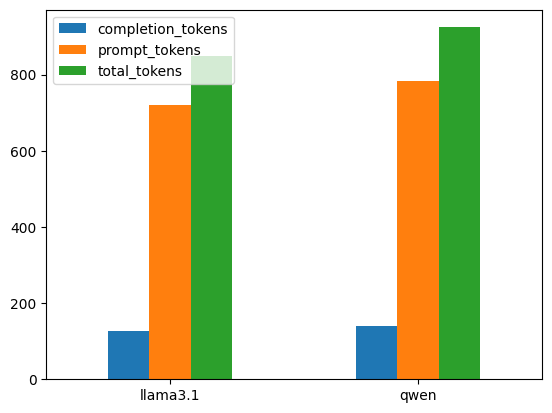

In [ ]:
df_compare_models[['completion_tokens', 'prompt_tokens', 'total_tokens']].plot.bar(rot=0)

<Axes: >

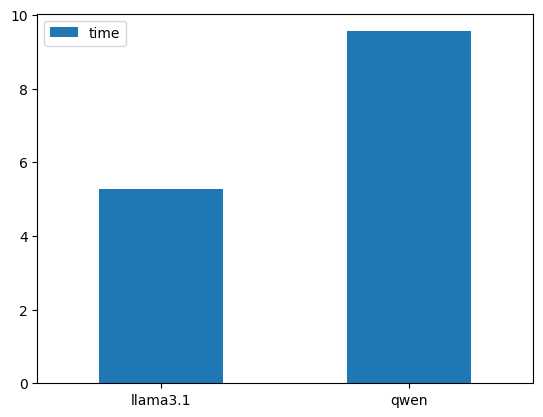

In [ ]:
df_compare_models[['time']].plot.bar(rot=0)

In [ ]:
data = json.loads(chosen_model.choices[0].message.content)['shareholders']
df4omini = pd.DataFrame(data)
df4omini

,shareholder_name,birthdate,address,share_amount,status
0,Jan Kowalski,30.09.1955,None,20000.0,current
1,Zdzisław Malinowski,28.07.1976,None,5000.0,current


In [ ]:
data = json.loads(qwen.choices[0].message.content)['shareholders']
df5mini = pd.DataFrame(data)
df5mini

### Try the numbers twice

- Run the two timing cells again. The times move ; the token counts barely do
- A single measurement of a model is close to meaningless
- Extraction has a right answer, so check whether the larger one earned its time